# NHA Hackathon – Problem Statement 3  
---
### Team: Nikhileswara Rao Sulake, Sai Manikanta Eswar Machara, Sivalal Kethavath
### Rajiv Gandhi University of Knowledge Technologies, Nuzvid, Andhra Pradesh
---

This pipeline is completely classicical computer vision based solution, where no models or other components are required, just using the traditional pre-defined library our solution is capable enough to detect the document forgery. This solution got 0.5315 score in the internal validation placing at Top3 in the leaderbaord. 

Why we choose this classical CV solution than the huge CLIP's, ViT's, ManTra-Net, MVSS-Net, CAT-Net or DTD? Because our main motive is making the solution highly scalable, computationally lightweight, and 100% explainable, aligning perfectly with the core demands of the AB-PMJAY ecosystem.

In [10]:
import os
from pathlib import Path
import pytesseract
import shutil

fallback_path = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
found = shutil.which("tesseract")
if not found and fallback_path.exists():
    found = str(fallback_path)

if found:
    os.environ["TESSERACT_CMD"] = found
    pytesseract.pytesseract.tesseract_cmd = found

print("Tesseract cmd:", found)

Tesseract cmd: C:\Program Files\Tesseract-OCR\tesseract.exe


In [ ]:
from pathlib import Path
import sys
import re
import shutil

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "backend").exists():
    repo_root = repo_root.parent

backend_dir = repo_root / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

from app.pipeline import run_pipeline, CATEGORY_IDS, is_ocr_enabled
from PIL import Image

IMAGE_PATH = Path(r"backend_sample_testing\work_fair\input\img1.jpeg")
work_dir = repo_root / "backend_sample_testing" / "work_fair"
if work_dir.exists():
    shutil.rmtree(work_dir)
work_dir.mkdir(parents=True, exist_ok=True)

print("Repo:", repo_root)
print("Image exists:", IMAGE_PATH.exists())
print("OCR enabled:", is_ocr_enabled())

Repo: c:\Users\nikhi\Downloads\Doc-Forgery-Detector
Image exists: True
OCR enabled: True



##### **Databank ID for PS3: 1ae9a4db-6b53-4a17-8274-fd3818c3f2be**

In [12]:
output = run_pipeline(IMAGE_PATH, work_dir, preset="super_loose", enable_ocr=True)
pages = output["pages"]
results = output["results"]

print(f"Pages: {len(pages)} | Results: {len(results)}")
print("Output dir:", output["output_dir"])

Pages: 1 | Results: 1
Output dir: c:\Users\nikhi\Downloads\Doc-Forgery-Detector\test_backend\work_fair\output


In [13]:
import os
import shutil
import sys
from pathlib import Path

try:
    import pytesseract
except Exception:
    pytesseract = None

try:
    import pandas as pd
except Exception:
    pd = None

repo_root = Path.cwd()
if not (repo_root / "backend").exists():
    repo_root = repo_root.parent
backend_dir = repo_root / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

if pytesseract is not None:
    tesseract_cmd = os.environ.get("TESSERACT_CMD")
    if not tesseract_cmd:
        tesseract_cmd = shutil.which("tesseract")
    if not tesseract_cmd:
        fallback = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
        if fallback.exists():
            tesseract_cmd = str(fallback)
    if tesseract_cmd:
        os.environ["TESSERACT_CMD"] = tesseract_cmd
        pytesseract.pytesseract.tesseract_cmd = tesseract_cmd

ocr_active = pytesseract is not None
print("OCR active:", ocr_active)

OCR_CONFIG = "--oem 3 --psm 6"
MERGE_GAP = 8
PADDING = 10


def boxes_close(a, b, gap: int) -> bool:
    return not (
        a[2] + gap < b[0]
        or b[2] + gap < a[0]
        or a[3] + gap < b[1]
        or b[3] + gap < a[1]
    )


def merge_box(a, b):
    return (min(a[0], b[0]), min(a[1], b[1]), max(a[2], b[2]), max(a[3], b[3]))


def merge_boxes(boxes, gap: int):
    clusters = [{"box": b, "count": 1} for b in boxes]
    if not clusters:
        return []
    changed = True
    while changed:
        changed = False
        merged = []
        while clusters:
            curr = clusters.pop()
            i = 0
            while i < len(clusters):
                if boxes_close(curr["box"], clusters[i]["box"], gap):
                    curr["box"] = merge_box(curr["box"], clusters[i]["box"])
                    curr["count"] += clusters[i]["count"]
                    clusters.pop(i)
                    changed = True
                else:
                    i += 1
            merged.append(curr)
        clusters = merged
    return clusters


def pad_box(box, pad: int, width: int, height: int):
    x1, y1, x2, y2 = box
    return (
        max(0, x1 - pad),
        max(0, y1 - pad),
        min(width, x2 + pad),
        min(height, y2 + pad),
    )


from app.pipeline import build_findings_summary

summary = build_findings_summary(
    pages,
    results,
    merge_gap=MERGE_GAP,
    padding=PADDING,
    ocr_config=OCR_CONFIG,
)

if pd is not None:
    display(pd.DataFrame(summary.get("findings", [])))
else:
    print(summary.get("findings", []))

print("Summary:")
print(summary.get("summary_text", ""))

sanity = summary.get("sanity")
if sanity:
    print("Sanity:", sanity)

OCR active: True


,page,category_id,category_label,snippet,location,summary
0,1,C2,Overwritten text,APOLLO HOSPITALS - HYDERABAD Dr. Shalina Ray M...,center,"Page 1: Overwritten text near ""APOLLO HOSPITAL..."
1,1,C3,Added content,(hal Buds,center,"Page 1: Added content near ""(hal Buds"" appears..."
2,1,C4,Removed content,T the Curauon Of Frecnisolone taper. Negular C...,middle-right,"Page 1: Removed content near ""T the Curauon Of..."
3,1,C7,Irregular spacing,PLEO VUNSUNAILE DIN 1 wa. Shame 16/ SCRIPTION ...,center,"Page 1: Irregular spacing near ""PLEO VUNSUNAIL..."
4,1,C9,AI-edited content,1 PATIENT IDENTIFICATION Name: RAHUL SHARMA Da...,center,"Page 1: AI-edited content near ""1 PATIENT IDEN..."


Summary:
Page 1: Overwritten text near "APOLLO HOSPITALS - HYDERABAD Dr. Shalina Ray MBBS FCPS Consultant" appears altered.
Page 1: Added content near "(hal Buds" appears altered.
Page 1: Removed content near "T the Curauon Of Frecnisolone taper. Negular COMple: for follow-up." appears altered.
Page 1: Irregular spacing near "PLEO VUNSUNAILE DIN 1 wa. Shame 16/ SCRIPTION REPORT /(" appears altered.
Page 1: AI-edited content near "1 PATIENT IDENTIFICATION Name: RAHUL SHARMA Date: 15/07/2024 Age: 45y" appears altered.
Sanity: {'ocr_active': True, 'tesseract_cmd': 'C:\\Program Files\\Tesseract-OCR\\tesseract.exe', 'merge_gap': 8, 'padding': 10, 'pages': 1, 'results': 1, 'clusters': 39, 'source_boxes': 492, 'clusters_with_text': 28, 'source_boxes_with_text': 480}


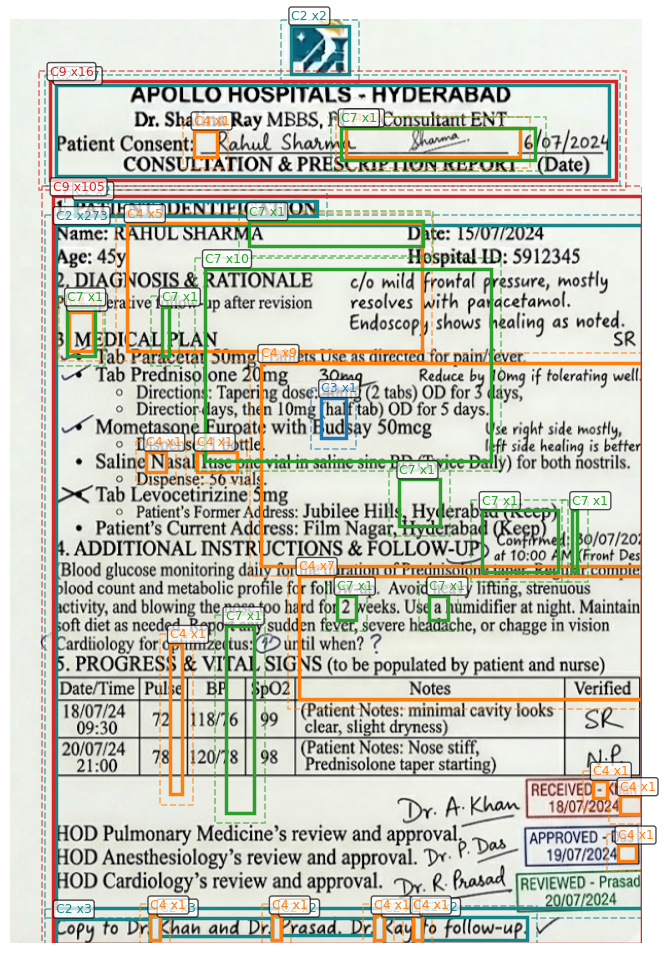

In [9]:
import matplotlib.patches as patches

page = pages[0]
image_path = Path(page.image_path or page.original_path)
image = Image.open(image_path).convert("RGB")

fig, ax = plt.subplots(figsize=(9, 12))
ax.imshow(image)

palette = [
    "#14868C",
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
]
color_map = {}

boxes_by_category = {}
for region in results[0].detected_regions:
    box = (region.x, region.y, region.x + region.w, region.y + region.h)
    boxes_by_category.setdefault(region.category_id, []).append(box)

for category_id, boxes in boxes_by_category.items():
    color = color_map.get(category_id)
    if color is None:
        color = palette[len(color_map) % len(palette)]
        color_map[category_id] = color

    clusters = merge_boxes(boxes, MERGE_GAP)
    for cluster in clusters:
        x1, y1, x2, y2 = cluster["box"]
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2.5,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        pad_box_coords = pad_box(cluster["box"], PADDING, image.width, image.height)
        px1, py1, px2, py2 = pad_box_coords
        padded_rect = patches.Rectangle(
            (px1, py1),
            px2 - px1,
            py2 - py1,
            linewidth=1.2,
            edgecolor=color,
            linestyle="--",
            facecolor="none",
            alpha=0.6,
        )
        ax.add_patch(padded_rect)

        ax.text(
            x1,
            max(0, y1 - 6),
            f"{category_id} x{cluster['count']}",
            color=color,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
        )

ax.axis("off")
plt.show()